In [1]:
print("Jai Shree Krishna!!")

Jai Shree Krishna!!


In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df =  pd.read_csv("Customer_Data.CSv")

In [5]:
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [6]:
drop_cols = [
    'Customer_ID',
    'Churn_Category',
    'Churn_Reason'
]

df.drop(columns=drop_cols, inplace=True)

In [7]:
df['Churn'] = df['Customer_Status'].apply(
    lambda x: 1 if x == 'Churned' else 0
)

df.drop('Customer_Status', axis=1, inplace=True)

In [20]:
df.head()

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Churn
0,Male,35,No,Delhi,7,27,NaN,Yes,No,Yes,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,0
1,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,Yes,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,0
2,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,Yes,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,1
3,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,Yes,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,1
4,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,Yes,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,1


<Axes: xlabel='count', ylabel='Churn_Category'>

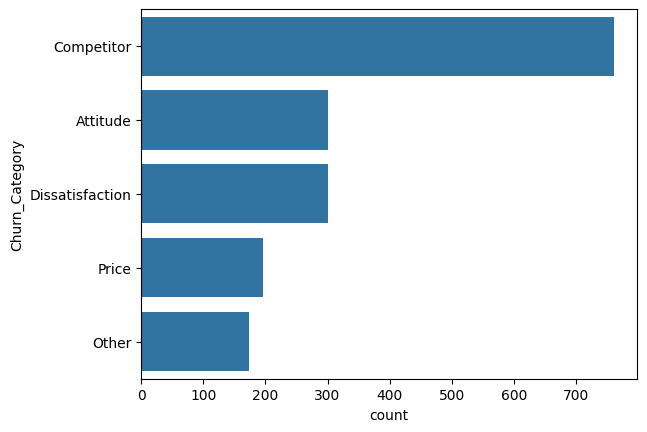

In [21]:
original_df =  pd.read_csv("Customer_Data.CSv")
churn_df = original_df[
    original_df['Customer_Status']=='Churned'
]

sns.countplot(
    y='Churn_Category',
    data=churn_df,
    order=churn_df['Churn_Category']
            .value_counts()
            .index
)

In [22]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('No')
    else:
        df[col] = df[col].fillna(0)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

<Axes: >

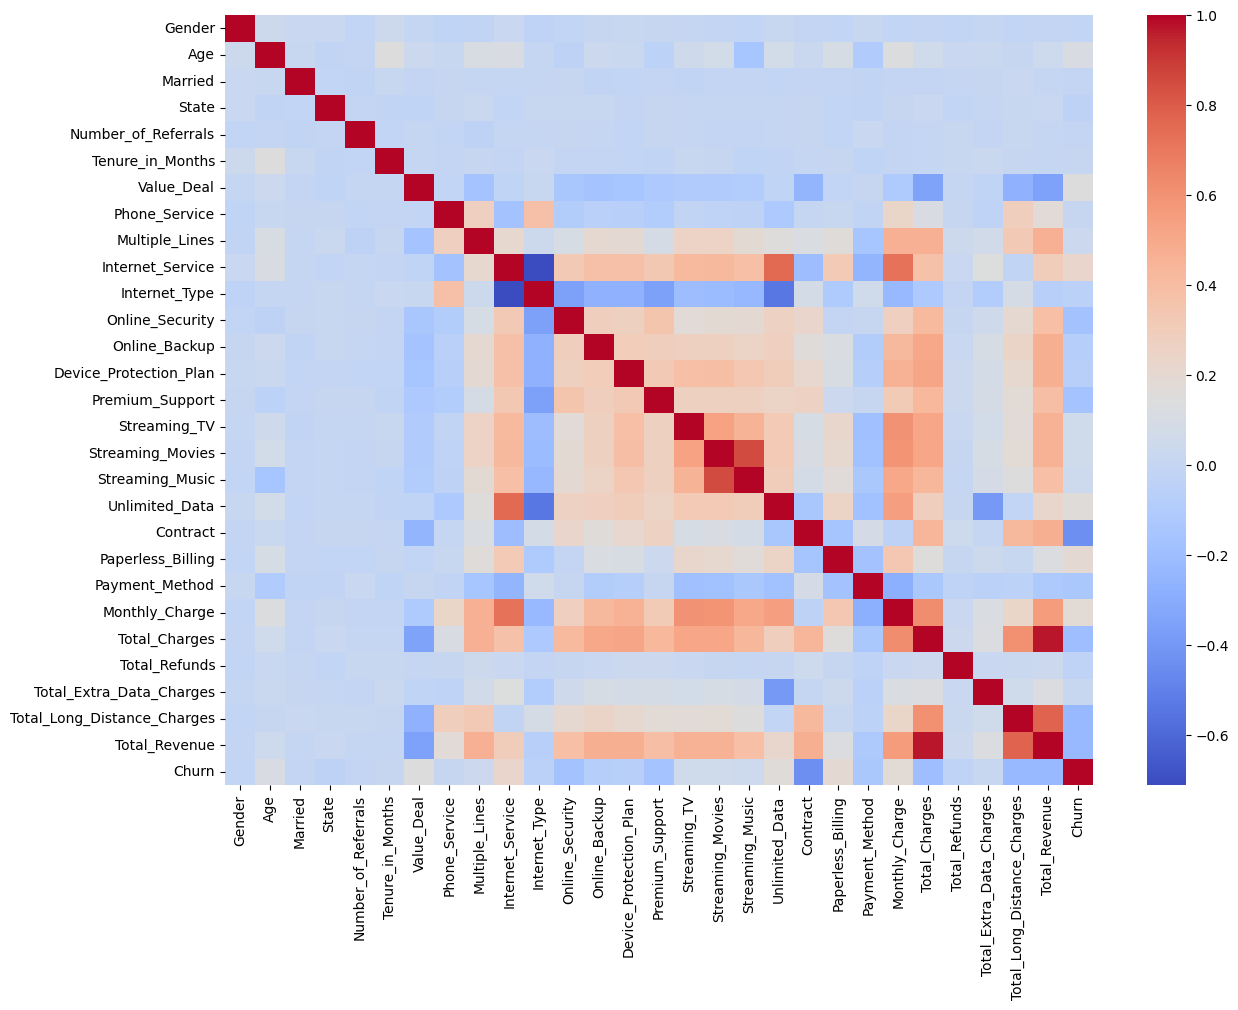

In [24]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

c:\Users\randh\Desktop\project\DA\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
lr_pred = lr.predict(X_test)

In [32]:
rf_pred = rf.predict(X_test)

In [33]:
xgb_pred = xgb.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
accuracy_lr = accuracy_score(y_test, lr_pred)

print("Accuracy :", accuracy_lr)

Accuracy : 0.7982866043613707


In [38]:
accuracy_rf = accuracy_score(y_test, rf_pred)

print("Accuracy :", accuracy_rf)

Accuracy : 0.82398753894081


In [39]:
accuracy_xgb = accuracy_score(y_test, xgb_pred)

print("Accuracy :", accuracy_xgb)

Accuracy : 0.8216510903426791


In [40]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       937
           1       0.63      0.61      0.62       347

    accuracy                           0.80      1284
   macro avg       0.74      0.74      0.74      1284
weighted avg       0.80      0.80      0.80      1284



In [41]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       937
           1       0.71      0.60      0.65       347

    accuracy                           0.82      1284
   macro avg       0.78      0.75      0.77      1284
weighted avg       0.82      0.82      0.82      1284



In [42]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       937
           1       0.70      0.61      0.65       347

    accuracy                           0.82      1284
   macro avg       0.78      0.75      0.76      1284
weighted avg       0.82      0.82      0.82      1284



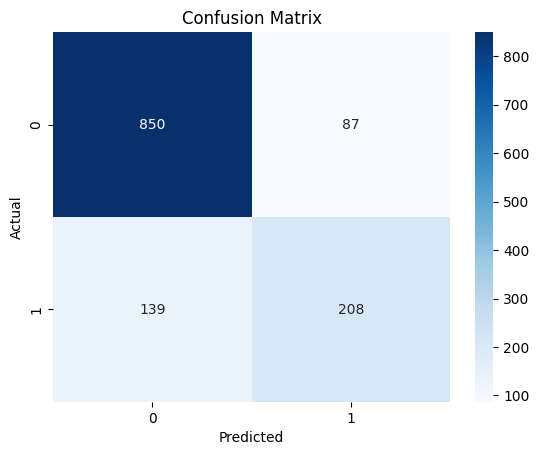

In [43]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [45]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                        Feature  Importance
19                     Contract    0.123773
22               Monthly_Charge    0.099711
27                Total_Revenue    0.097580
23                Total_Charges    0.094221
26  Total_Long_Distance_Charges    0.081738
1                           Age    0.079251
5              Tenure_in_Months    0.055858
3                         State    0.050858
4           Number_of_Referrals    0.048030
10                Internet_Type    0.034880


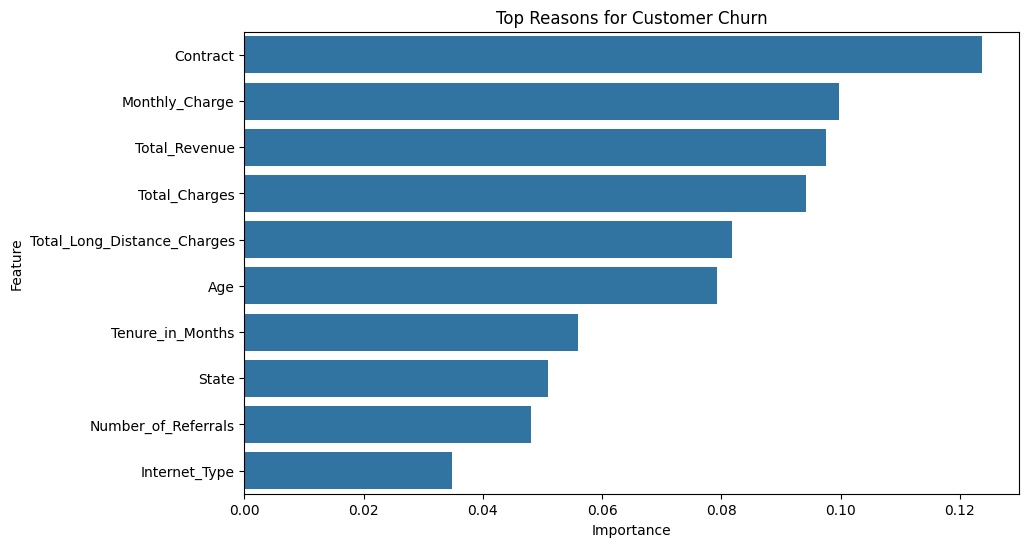

In [46]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Reasons for Customer Churn")

plt.show()

In [47]:
high_risk = df[df['Churn'] == 1]

print("Total High Risk Customers :", len(high_risk))

Total High Risk Customers : 1732


<Axes: xlabel='Churn', ylabel='count'>

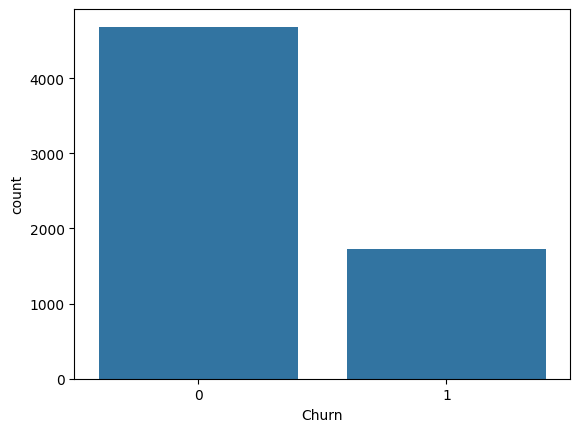

In [48]:
sns.countplot(x='Churn', data=df)

<Axes: xlabel='Contract'>

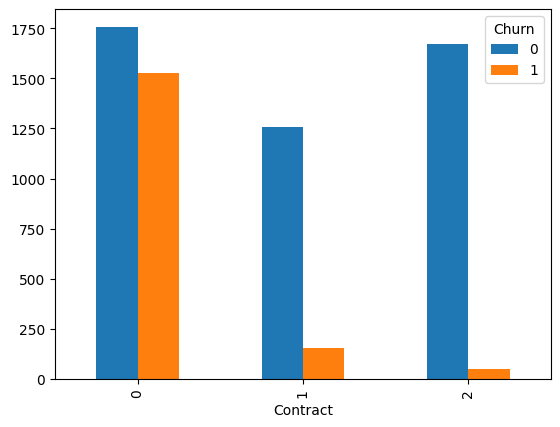

In [49]:
pd.crosstab(
    df['Contract'],
    df['Churn']
).plot(kind='bar')

<Axes: xlabel='Internet_Type', ylabel='count'>

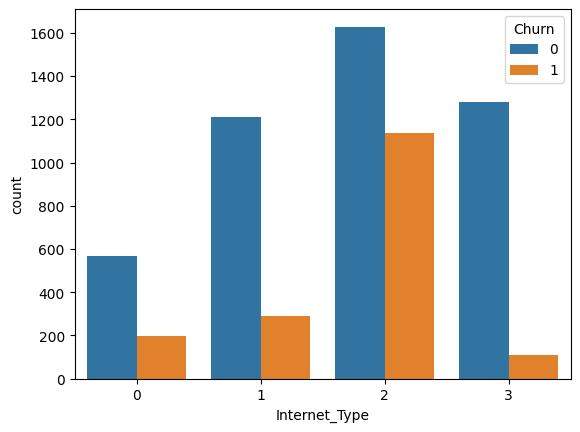

In [50]:
sns.countplot(
    x='Internet_Type',
    hue='Churn',
    data=df
)

<Axes: xlabel='Payment_Method', ylabel='count'>

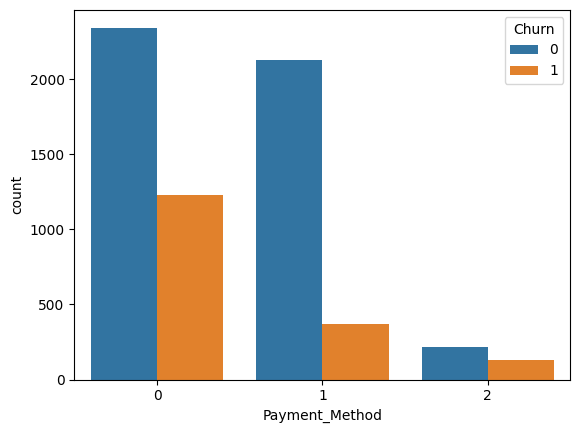

In [51]:
sns.countplot(
    x='Payment_Method',
    hue='Churn',
    data=df
)

<Axes: xlabel='Churn', ylabel='Age'>

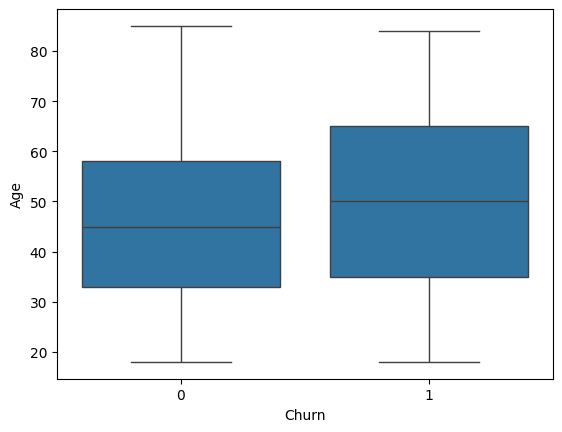

In [52]:
sns.boxplot(
    x='Churn',
    y='Age',
    data=df
)

<Axes: xlabel='Churn', ylabel='Monthly_Charge'>

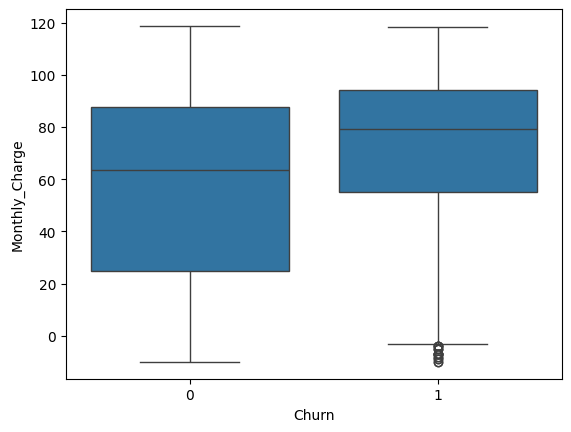

In [53]:
sns.boxplot(
    x='Churn',
    y='Monthly_Charge',
    data=df
)